In [55]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

## Loading Data

In [10]:
data = pd.read_csv('../../data/employee_salary_dataset.csv')
df = pd.DataFrame(data)
print(df.head())

   EmployeeID        Name  Department  Experience_Years Education_Level  Age  \
0           1  Employee_1   Marketing                15          Master   53   
1           2  Employee_2  Operations                 7        Bachelor   25   
2           3  Employee_3          IT                12     High School   51   
3           4  Employee_4  Operations                 8             PhD   44   
4           5  Employee_5  Operations                15          Master   36   

   Gender       City  Monthly_Salary  
0  Female      Delhi          111416  
1  Female  Bangalore           95271  
2  Female  Hyderabad           69064  
3    Male      Delhi           95091  
4  Female      Delhi          132450  


In [12]:
df.shape

(50, 9)

In [14]:
df.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   EmployeeID        50 non-null     int64
 1   Name              50 non-null     str  
 2   Department        50 non-null     str  
 3   Experience_Years  50 non-null     int64
 4   Education_Level   50 non-null     str  
 5   Age               50 non-null     int64
 6   Gender            50 non-null     str  
 7   City              50 non-null     str  
 8   Monthly_Salary    50 non-null     int64
dtypes: int64(4), str(5)
memory usage: 3.6 KB


In [11]:
df.describe()

,EmployeeID,Experience_Years,Age,Monthly_Salary
count,50.00000,50.000000,50.000000,50.0000
mean,25.50000,9.900000,39.760000,82288.8000
std,14.57738,5.349995,11.539745,33521.4379
min,1.00000,1.000000,22.000000,28420.0000
25%,13.25000,5.250000,28.250000,59424.0000
50%,25.50000,10.000000,43.500000,73890.5000
75%,37.75000,14.750000,49.000000,107219.0000
max,50.00000,19.000000,57.000000,149123.0000


## Handling Missing Value

In [17]:
df.isnull().sum()

EmployeeID          0
Name                0
Department          0
Experience_Years    0
Education_Level     0
Age                 0
Gender              0
City                0
Monthly_Salary      0
dtype: int64

## Handling Duplicates

In [18]:
df.duplicated().sum()

np.int64(0)

## Exploratory Data Analysis (EDA)

In [37]:
df['Monthly_Salary'].astype(float)

df.value_counts()
df.nunique()
df.corr(numeric_only=True)

,EmployeeID,Experience_Years,Age,Monthly_Salary,Salary
EmployeeID,1.000000,-0.107681,-0.168997,-0.003808,-0.003808
Experience_Years,-0.107681,1.000000,0.130837,0.074221,0.074221
Age,-0.168997,0.130837,1.000000,0.060972,0.060972
Monthly_Salary,-0.003808,0.074221,0.060972,1.000000,1.000000
Salary,-0.003808,0.074221,0.060972,1.000000,1.000000


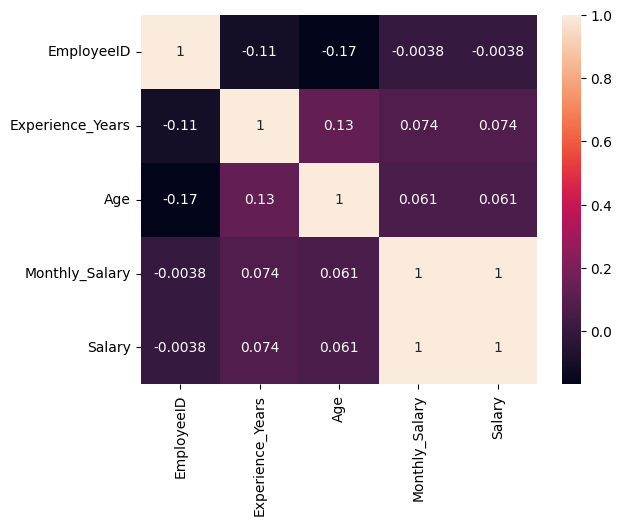

In [34]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

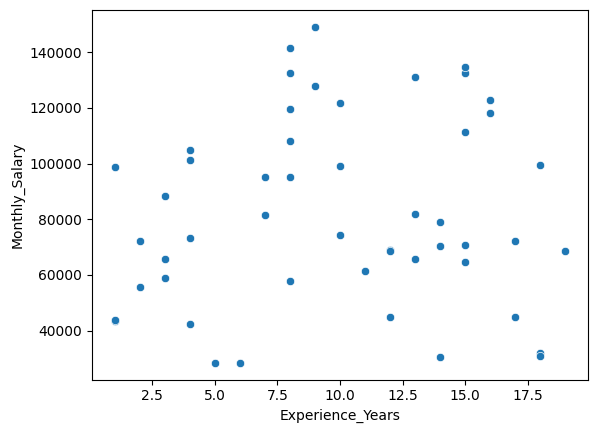

In [35]:
sns.scatterplot(data=df, x='Experience_Years', y='Monthly_Salary')
plt.show()

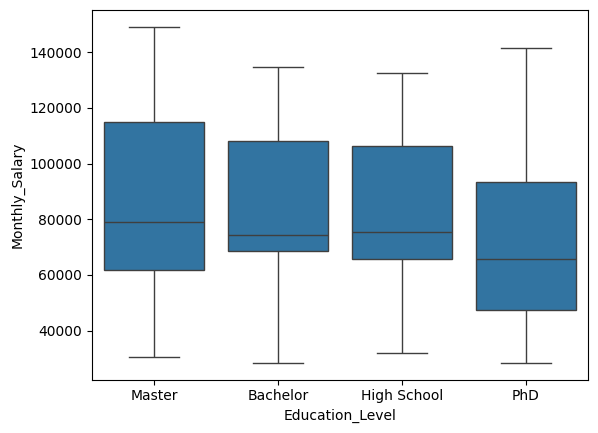

In [39]:
sns.boxplot(data=df, x='Education_Level', y='Monthly_Salary')
plt.show()

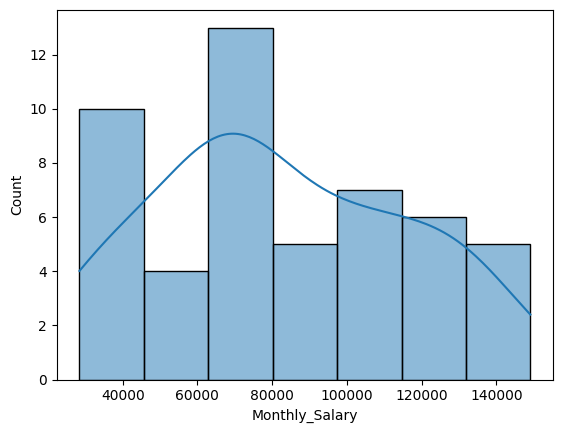

In [36]:
sns.histplot(data=df, x='Monthly_Salary', kde=True)
plt.show()

## Handling Outliers

### Filter outliers from monthly salary

In [ ]:
Q1 = df['Monthly_Salary'].quantile(0.25)
Q3 = df['Monthly_Salary'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['Monthly_Salary'] > lower) & (df['Monthly_Salary'] < upper)]

### Filter outliers from experience level

In [46]:
Q1 = df['Experience_Years'].quantile(0.25)
Q3 = df['Experience_Years'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['Experience_Years'] > lower) & (df['Experience_Years'] < upper)]

### Filter outliers from age

In [47]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['Age'] > lower) & (df['Age'] < upper)]

## Encoding Categorical Variables

In [52]:
# Map education levels to numerical values
df['Education_Level'] = df['Education_Level'].map({'High School': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3})

# One-hot encoding
df = pd.get_dummies(df, columns=['City'], drop_first=True)

KeyError: "None of [Index(['City'], dtype='str')] are in the [columns]"

In [56]:
print(df.columns.tolist())

['EmployeeID', 'Name', 'Department', 'Experience_Years', 'Education_Level', 'Age', 'Gender', 'Monthly_Salary', 'Salary', 'City_Chennai', 'City_Delhi', 'City_Hyderabad', 'City_Mumbai']


## Feature Scaling

In [57]:
X = df[['Experience_Years', 'Education_Level', 'Age', 'City_Chennai', 'City_Mumbai', 'City_Delhi', 'City_Hyderabad']]
y = df['Monthly_Salary']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

d:\Devprojects\AI\_machine_learning\_deep_learning\employee-salary-prediction\.venv\Lib\site-packages\sklearn\utils\extmath.py:1207: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
d:\Devprojects\AI\_machine_learning\_deep_learning\employee-salary-prediction\.venv\Lib\site-packages\sklearn\utils\extmath.py:1212: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
d:\Devprojects\AI\_machine_learning\_deep_learning\employee-salary-prediction\.venv\Lib\site-packages\sklearn\utils\extmath.py:1236: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count
